In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
sys.path.append("/Users/ana/Desktop/takarada/")
from helpers_takarada import * 
from module_takarada import *
import matplotlib
import seaborn as sns
plt.rcParams.update({'savefig.dpi':300, 'axes.labelweight':'normal'})
matplotlib.rcParams['axes.linewidth'] = 0.8
from matplotlib import rc
preamble = r'''\usepackage{physics} \usepackage{upgreek} \usepackage{bm}'''
plt.rc('text.latex', preamble=preamble)
rc('text', usetex=True)

plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['figure.figsize'] = (6,4)
plt.rcParams['legend.fontsize'] = 12

''' numerical parameters for the self-consistent calculation '''
parameters1 = {'n_pass' : 1e-4,
'epsilon_threshold' : 1e-6,
'N_epsilon' : 5,
'maxiter' : 500,
'eps_last' : 1e-6,
'dmu' : 0.5,
'mix2' : 0.001,
'mix3' : 1.5,
'faktor1' : 0.1,
'max_trials' : 15,
'eps0' : 0.03,
}

parameters2 = {'n_pass' : 1e-3,
'epsilon_threshold' : 1e-6,
'N_epsilon' : 5,
'maxiter' : 100,
'eps_last' : 1e-6,
'dmu' : 0.5,
'mix2' : 0.001,
'mix3' : 1.5,
'faktor1' : 0.1,
'max_trials' : 15,
'eps0' : 0.03,
}

def colorFader(c1, c2, mix=0.5):
    c1 = np.array(matplotlib.colors.to_rgb(c1))
    c2 = np.array(matplotlib.colors.to_rgb(c2))
    return matplotlib.colors.to_hex((1-mix)*c1 + mix*c2)

def get_palette_hex(palette_name, N):
    return sns.color_palette(palette_name, n_colors=N).as_hex()

(np.complex128(0.569325697648109+9.198777807181701e-20j),
 np.complex128(0.047652280579799144-1.7184943247074146e-18j),
 np.float64(1.3506805178875259))

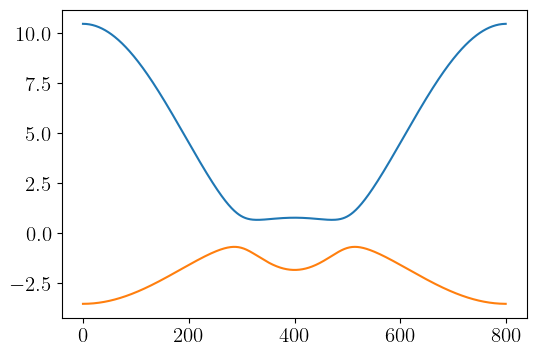

In [ ]:
''' 1. generate ground state of some excitonic insulator model '''
a = 1.
b = 0.2

t12 = 0.1
delta = 0.

t = 1.0
t_ = 3.0
Vc = 0.5
Vb = 3.0

mu0 = 0.
include_hartree = True

Nk = 800

gap = -4

epsilon = 0.5*(gap + 2*t_ + 2*t)
epsilon_ = epsilon

phys_parameters = [b, t, t_, t12, epsilon, epsilon_, Vb, Vc, delta]
m = model(Nk, mu0, phys_parameters, parameters1, parameters2, include_hartree)
m.GS()
plt.plot(m.energije[1]-m.mu)
plt.plot(m.energije[0]-m.mu)
m.delta_b, m.delta_c, m.gap


In [54]:
''' 2. go to small but finite temperature '''
beta0 = 50
scale = 1.01
betas = beta0/scale**np.arange(1,11)
stops = [int(np.emath.logn(scale, beta0/beta)) for beta in betas]
Ts = 1/betas
Gamma = 0.005

# Nomega, eps put to random small values because I am not interested in transport coefficients now
Nomega, eps = 3, 0.1

Nomega, eps = 1501, 1e-6
maxbrentq = 30
factor = 15
oms = [1e-8]
Gammas = [1e-5]
N = 10
m.run_Tdependence(betas, stops, Gammas, Nomega, eps, maxbrentq, evaluate_transport=False)

started
0.0
49.504950495049506 8.206062435123229e-07 1.0 0.569325554379873 0.047652252179352955
0.1
49.01480247034605 8.206175021729933e-07 1.0 0.5693255543775756 0.04765225217906776
0.2
48.529507396382215 8.206062431237449e-07 1.0 0.5693255543798723 0.0476522521793529
0.3
48.04901722414082 8.206175021729933e-07 1.0 0.5693255543775747 0.04765225217906769
0.4
47.573284380337434 8.206062431237449e-07 1.0 0.5693255543798712 0.047652252179352754
0.5
47.10226176271033 8.206175018399264e-07 1.0 0.569325554377573 0.04765225217906752
0.6
46.635902735356765 8.206062436233452e-07 0.9999999999999999 0.5693255543798691 0.047652252179352594
0.7
46.17416112411561 8.206062434013006e-07 1.0 0.5693255543798674 0.04765225217935244
0.8
45.716991211995655 8.206175021174822e-07 1.0 0.569325554377567 0.04765225217906703
0.9
45.264347734649164 8.206062432902783e-07 1.0 0.5693255543798611 0.04765225217935188


0.0
0.00030000120000480004
0.0006000024000096001
0.0009000036000144001
0.0012000048000192002
0.001500006000024
0.0018000072000288001
0.0021000084000336
0.0024000096000384003
0.0027000108000432
0.003000012000048
0.0033000132000528004
0.0036000144000576002
0.0039000156000624
0.0042000168000672
0.004500018000072
0.004800019200076801
0.0051000204000816
0.0054000216000864
0.005700022800091201
0.006000024000096
0.0063000252001008
0.006600026400105601
0.0069000276001104
0.0072000288001152005
0.007500030000120001
0.0078000312001248
0.0081000324001296
0.0084000336001344
0.0087000348001392
0.009000036000144
0.009300037200148801
0.009600038400153601
0.0099000396001584
0.0102000408001632
0.010500042000168
0.0108000432001728
0.011100044400177601
0.011400045600182401
0.0117000468001872
0.012000048000192
0.0123000492001968
0.0126000504002016
0.012900051600206401
0.013200052800211201
0.013500054000216
0.0138000552002208
0.0141000564002256
0.014400057600230401
0.014700058800235201
0.015000060000240002


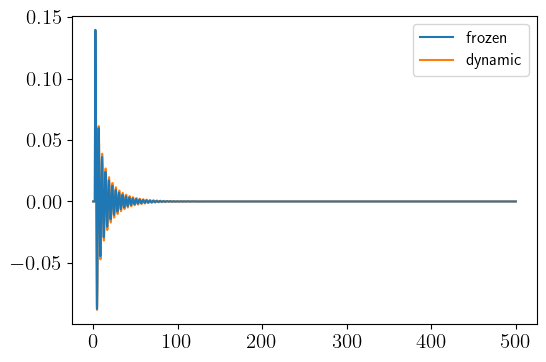

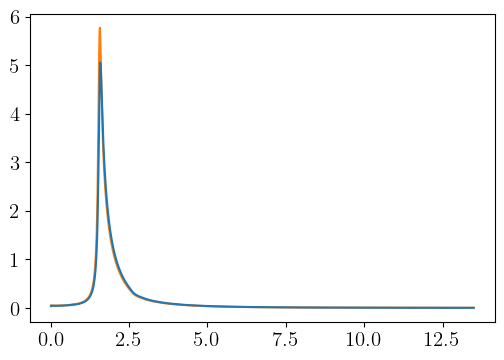

In [73]:
perturbation_operator = m.tok
measure_provider = m.tok
A0 = 0.003
t0 = 2.0
sigma = 0.01
Omega = 0.0
dt = 0.003
t_max = 500
Ncorr = 10
tol = 1e-5

Gamma = 0.05

do_freeze = True
time, measurement, norms, delta_bs, delta_cs = simulate_pulz(m.K, m.hk0, m.rho, m.phys_parameters, m.include_hartree, perturbation_operator, measure_provider,
                                  A0, t0, sigma, Omega, dt, t_max, do_freeze, Ncorr, tol, m.geom, m.phases, m.g_ffts, Gamma)

do_freeze = False
time_full, measurement_full, norms_full, delta_bs_full, delta_cs_full = simulate_pulz(m.K, m.hk0, m.rho, m.phys_parameters, m.include_hartree, perturbation_operator, measure_provider,
                                 A0, t0, sigma, Omega, dt, t_max, do_freeze, Ncorr, tol, m.geom, m.phases, m.g_ffts, Gamma)

probe = A_pulz(time, A0, t0, sigma, 0.)
eta = 1 / t_max
omega_cut = 10*m.gap
Omegas, Sigma = optical_conductivity(time, measurement[:,0].real, probe, eta, omega_cut, m.Nk)
Omegas_full, Sigma_full = optical_conductivity(time_full, measurement_full[:,0].real, probe, eta, omega_cut, m.Nk)

plt.plot(time, measurement[:,0].real, label='frozen')
plt.plot(time, measurement_full[:,0].real, zorder=-100, label='dynamic')
plt.legend()
plt.show()

plt.plot(Omegas, Sigma)
plt.plot(Omegas_full, Sigma_full, zorder=-100)
plt.show()


(0.0, 0.2)

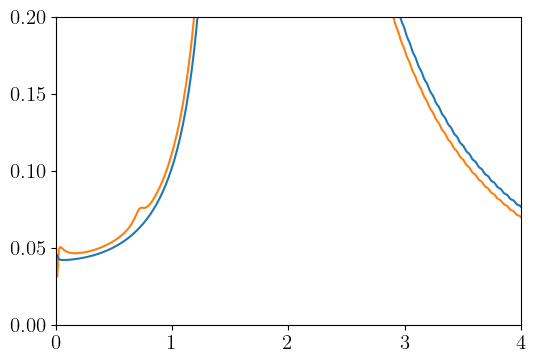

In [74]:
plt.plot(Omegas, Sigma)
plt.plot(Omegas_full, Sigma_full, zorder=-100)
plt.xlim(0,4.0)
plt.ylim(0,0.2)

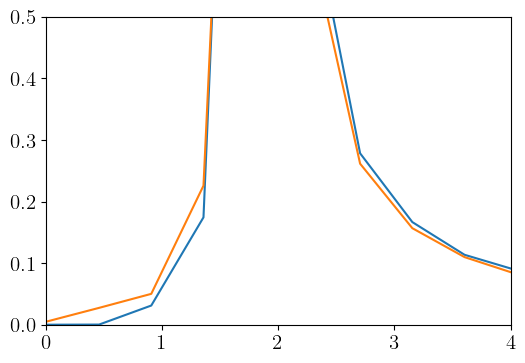

In [102]:
''' analytic corrections to conductivity '''
tok_tilde = operator_tilde(m.tok, m.vecs)
rhos, thetas = rho_operators(m.K, m.phys_parameters, m.include_hartree)
rhos_tilde = operator_tilde(rhos, m.vecs)

m1,m2,m3,m4 = compute_all_mf_matrices(m.K, m.rho, m.geom, m.phases, m.g_ffts)
mat_tilde = operator_tilde(m1+m2+m3+m4, m.vecs)

L=30
deg=200
nodes, weights = np.polynomial.legendre.leggauss(deg)

T = m.Ts[-1]

#omegas = np.linspace(0.01, m.gap * 3, 30)
Gamma = 0.01
sigma_x = np.zeros(len(omegas))
dsigma_x = np.zeros_like(sigma_x)

for i, omega in enumerate(omegas):
    results = chi_jrho2(m.Nk, len(thetas), tok_tilde, rhos_tilde, mat_tilde, -thetas, m.energije, m.mu / Gamma, Gamma / m.Ts[-1], omega, Gamma, L, nodes, weights)
    sigma_x[i] = results['j_j'].imag / omega
    dsigma_x[i] = results['dj_j'].imag / omega

plt.plot(omegas, sigma_x)
plt.plot(omegas, sigma_x + dsigma_x)
plt.ylim(0,0.5)
plt.xlim(0,4)
plt.show()

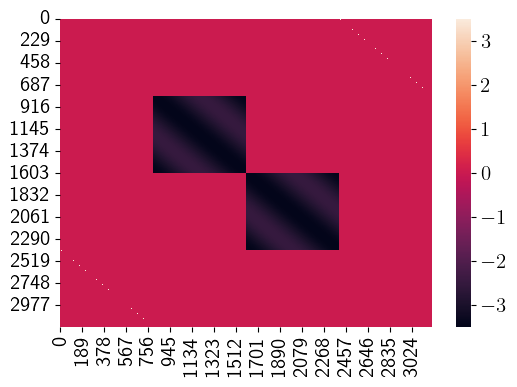

0
1
2
3
4
5
6
7
8
9


/var/folders/pm/d_9cvb8n3xlftb1wrgw8y4dr0000gq/T/ipykernel_79994/4192367115.py:84: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


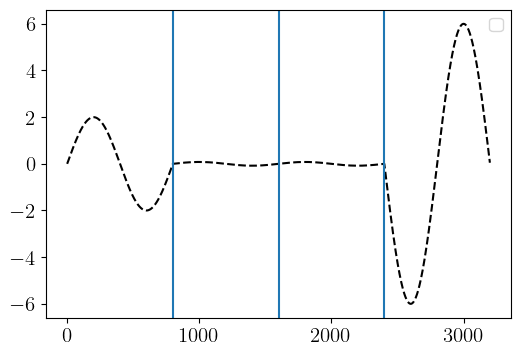

In [109]:
U = m.vecs
energije = m.energije

omega = 0.5
L = 20
deg = 180
nodes,weights= np.polynomial.legendre.leggauss(deg)
Gamma = 0.01
mu_ = m.mu / Gamma
invt = Gamma / m.Ts[-1]
@njit(parallel=True, cache=True)
def bubble(Nk, omega, energije, Gamma, mu_, invt, L, nodes, weights):
    pi = np.zeros((2,2,Nk), dtype=np.complex128)

    for j in prange(Nk):
        for m in range(2):
            for n in range(m,2):
                pi_mnk, pi_nmk,_,_ = Pi_bubble_tilde(omega, energije[m,j], energije[n,j], Gamma, mu_, invt, L, nodes, weights,)

                pi[m,n,j] = pi_mnk
                pi[n,m,j] = pi_nmk

    return pi

''' construct M and N from U '''

M = np.einsum('uap,wgp->uwagp', U.conj(), U, ).reshape((4, 4, m.Nk))
N = np.einsum('zap,vgp->agzvp', U, U.conj()).reshape((4, 4, m.Nk))

''' construct Gamma0 '''
gamma_tilde = np.zeros((4*m.Nk, 4*m.Nk), dtype=np.complex128)
block1 = (Vb + Vc)*np.ones((m.Nk, m.Nk))
block2 = np.zeros((m.Nk, m.Nk), dtype=np.complex128)

def V(q, Vb, Vc):
    return Vb + Vc * np.exp(-1j*q)

for i, k in enumerate(m.K):
    for j, p in enumerate(m.K):
        q = k - p
        block2[i,j] = V(q, Vb, Vc)
np.fill_diagonal(gamma_tilde[:m.Nk, -m.Nk:], block1)
np.fill_diagonal(gamma_tilde[-m.Nk:, :m.Nk], block1)
gamma_tilde[m.Nk:2*m.Nk, m.Nk:2*m.Nk] = -block2
gamma_tilde[2*m.Nk:3*m.Nk, 2*m.Nk:3*m.Nk] = -block2.conj()

import seaborn as sns
sns.heatmap(gamma_tilde.real)
plt.show()
omegas = np.linspace(0.01, m.gap * 3, 10)
Sigma_x = np.zeros(len(omegas))
Dsigma_x = np.zeros(len(omegas))
cols = [colorFader('red', 'green', i/(len(omegas) - 1)) for i in range(len(omegas))]
for om, omega in enumerate(omegas):
    print(om)
    Pi = bubble(m.Nk, omega, energije, Gamma, mu_, invt, L, nodes, weights).reshape((4, m.Nk))

    Pi_tilde = np.einsum('aAk,Ak,Abk->abk', M, Pi, N).reshape((4, 4 * m.Nk))
    Pi_tilde2 = np.zeros((4 * Nk, 4 * Nk), dtype=np.complex128)
    for i in range(4):
        for j in range(4):
            line = Pi_tilde[i:i+1,j*Nk:(j+1)*Nk][0]
            np.fill_diagonal(Pi_tilde2[i*Nk:(i+1)*Nk, j*Nk:(j+1)*Nk], line)

    matrika = np.eye(gamma_tilde.shape[0]) - gamma_tilde @ Pi_tilde2
    #inverz = LA.inv(matrika)
    Gamma_tilde = LA.solve(matrika, gamma_tilde)
    #Gamma_tilde = inverz @ gamma_tilde

    tok_swap = np.swapaxes(m.tok, 0, 1).flatten()
    tok = m.tok.flatten()
    Tok = (Gamma_tilde @ Pi_tilde2 @ tok).reshape((2,2,Nk))
    Tok_swap = np.swapaxes(Tok, 0, 1).flatten()

    Sigma_x[om] = (tok @ Pi_tilde2 @ tok).imag / omega
    Dsigma_x[om] = (tok @ Pi_tilde2 @ Tok_swap).imag / omega
    #if om == 5: plt.plot(tok.real + Tok.flatten().real, label=omega, color=cols[om])

plt.plot(tok.real, color='black', ls='dashed')
plt.axvline(m.Nk)
plt.axvline(2*m.Nk)
plt.axvline(3*m.Nk)

plt.legend()

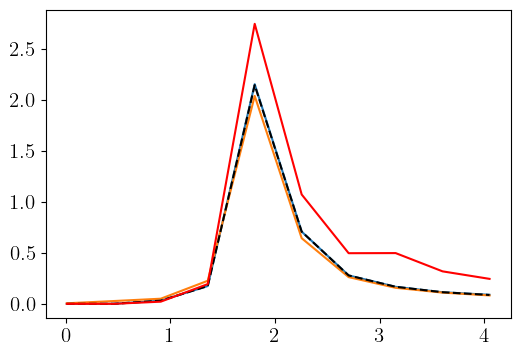

In [111]:
plt.plot(omegas, sigma_x)
plt.plot(omegas, sigma_x + dsigma_x)

plt.plot(omegas, Sigma_x / m.Nk, ls='dashed', color='black')
plt.plot(omegas, (Sigma_x + 0.5 * Dsigma_x) / m.Nk, color='red')
#plt.ylim(0,0.2)

In [280]:
tok @ Pi_tilde2 @ Tok.flatten()

np.complex128(4182.036107139461-3340.2549754752836j)

In [243]:
matrika = np.eye(gamma_tilde.shape[0]) - gamma_tilde @ Pi_tilde2
inverz = LA.inv(matrika)

Gamma_tilde = inverz @ gamma_tilde

tok = np.swapaxes(m.tok, 0, 1).flatten()
Tok = (Gamma_tilde @ Pi_tilde2 @ tok).reshape((2,2,Nk))#(Gamma_tilde @ tok).reshape((2,2,m.Nk))

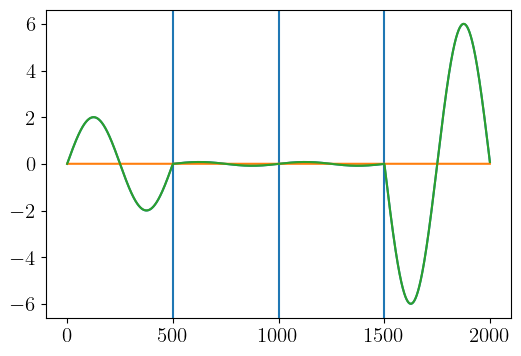

In [245]:
plt.plot(tok.real)
plt.axvline(m.Nk)
plt.axvline(2*m.Nk)
plt.axvline(3*m.Nk)

plt.plot(Tok.flatten().real)
plt.plot(tok.real + Tok.flatten().real)

In [143]:
rhos = m.rhos
thetas = m.thetas

hartreefock = np.zeros((2,2,m.Nk), dtype=np.complex128)

for i, theta in enumerate(thetas):
    rho_i = rhos[i]
    rho_tilde = np.einsum('jix, jlx, lmx -> imx', m.vecs.conj(), rho_i, m.vecs)
    suma = 0.0 + 0.0*1j
    for orb in range(2):
        for l in range(m.Nk):
            suma += rho_tilde[orb,orb,l] * fd(m.energije[orb,l], m.mu, m.Ts[-1])
    hartreefock += theta / m.Nk * rho_i * suma

hartreefock0 = h_k(m.K, m.hk0, m.rho, m.phys_parameters, 0.0, m.include_hartree) - m.hk0

print('errors in reconstructing hartree-fock hamiltonian from rho, thetas:')
for i in range(2):
    for j in range(2):
        print(np.max(np.abs(hartreefock[i,j] - hartreefock0[i,j])))

errors in reconstructing hartree-fock hamiltonian from rho, thetas:
2.804964038816138e-09
1.2990676312440996e-09
1.2990676312440996e-09
2.792940989593262e-09


In [167]:
''' analytic corrections to conductivity '''
tok_tilde = operator_tilde(m.tok, m.vecs)
rhos, thetas = rho_operators(m.K, m.phys_parameters, m.include_hartree)
rhos_tilde = operator_tilde(rhos, m.vecs)

m1,m2,m3,m4 = compute_all_mf_matrices(m.K, m.rho, m.geom, m.phases, m.g_ffts)
mat_tilde = operator_tilde(m1+m2+m3+m4, m.vecs)

L=30
deg=200
nodes, weights = np.polynomial.legendre.leggauss(deg)

T = m.Ts[-1]

omegas = np.logspace(-3,0.5, 300) * m.gap
Gamma = 0.01
sigma_x = np.zeros(len(omegas))
dsigma_x = np.zeros_like(sigma_x)

for i, omega in enumerate(omegas):
    results = chi_jrho2(m.K, tok_tilde, rhos_tilde, mat_tilde, thetas, m.energije, m.mu, T, omega, Gamma, L, nodes, weights)
    sigma_x[i] = results['chi_j_j'].imag / omega
    dsigma_x[i] = results['dchi_j_j'].imag / omega
sigma_x2 = np.zeros(len(omegas))
dsigma_x2 = np.zeros_like(sigma_x)
for i, omega in enumerate(omegas):
    results = chi_jrho2(m.K, tok_tilde, rhos_tilde, mat_tilde, -thetas, m.energije, m.mu, T, omega, Gamma, L, nodes, weights)
    sigma_x2[i] = results['chi_j_j'].imag / omega
    dsigma_x2[i] = results['dchi_j_j'].imag / omega



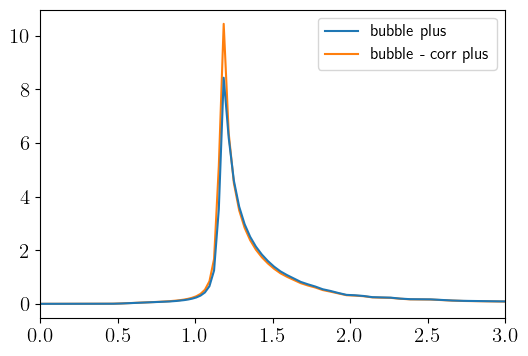

In [168]:
plt.plot(omegas, sigma_x, label='bubble plus')
plt.plot(omegas, sigma_x - dsigma_x, label='bubble - corr plus', zorder=-10)
#plt.plot(omegas, sigma_x + dsigma_x, label='bubble + corr plus', zorder=-10)
#plt.plot(omegas, sigma_x2 - dsigma_x2, label='bubble - corr minus', zorder=-10, ls='dashed')
#plt.plot(omegas, sigma_x2 + dsigma_x2, label='bubble + corr minus', zorder=-10, ls='dashed')

plt.xlim(0,3)
plt.legend()
plt.show()

In [152]:
epsilons = np.linspace(-5,5,1000)
A = Spektralka(epsilons, m.mu, m.energije, Gamma)
phi = phi_Kubo(m.K, tok_tilde, tok_tilde, A, epsilons)
K0 = np.trapezoid(phi * (-fd_1(epsilons, m.Ts[-1])), epsilons) * np.pi
print('DC Kubo K0 and sigma[omega to 0 ] are:')
print(K0.real)
print(sigma_x[0])

DC Kubo K0 and sigma[omega to 0 ] are:
0.00040804193865137905
0.0004080443900943967


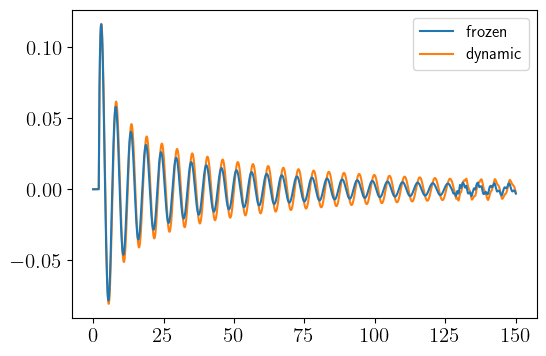

In [169]:
plt.plot(time, measurement[:,0].real, label='frozen')
plt.plot(time, measurement_full[:,0].real, zorder=-100, label='dynamic')
plt.legend()
plt.show()

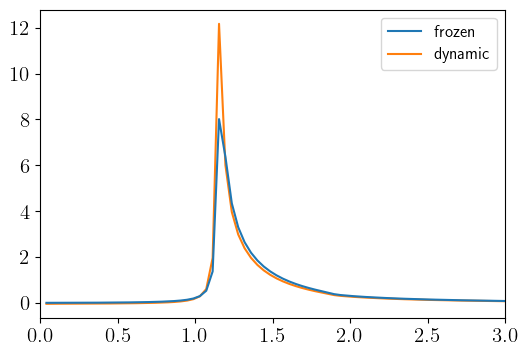

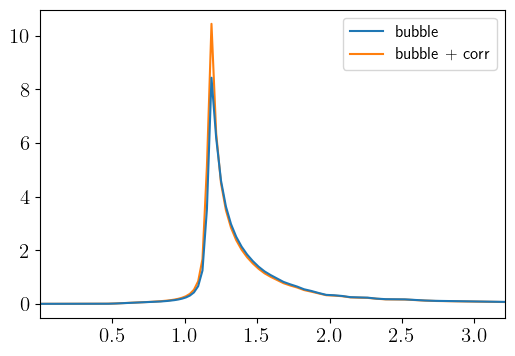

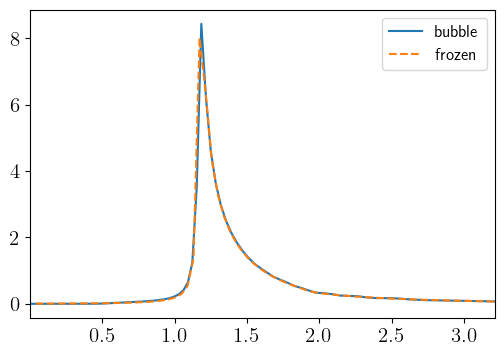

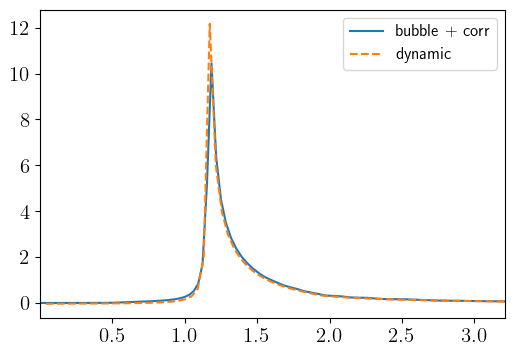

In [170]:

plt.plot(Omegas / m.gap, Sigma, label='frozen')
plt.plot(Omegas_full / m.gap, Sigma_full, zorder=-10, label='dynamic')
plt.xlim(0,3)
plt.legend()
plt.show()

plt.plot(omegas, sigma_x, label='bubble')
plt.plot(omegas, sigma_x - dsigma_x, zorder=-10, label='bubble + corr')
plt.xlim(omegas[0], omegas[-1])

plt.legend()
plt.show()

plt.plot(omegas, sigma_x, label='bubble')
plt.plot(Omegas, Sigma, ls='dashed', label='frozen')
plt.xlim(omegas[0], omegas[-1])
plt.legend()
plt.show()

plt.plot(omegas, sigma_x - dsigma_x, label='bubble + corr')
plt.plot(Omegas, Sigma_full, ls='dashed', label='dynamic')
plt.xlim(omegas[0], omegas[-1])
plt.legend()
plt.show()

In [30]:
sigma = 0.01

probe = A_pulz(time, A0, t0, sigma, 0.)
eta = 1 / t_max
omega_cut = 10*m.gap
Omegas, Sigma = optical_conductivity(time, measurement[:,0].real, probe, eta, omega_cut, m.Nk)
#Omegas, Sigma_full = optical_conductivity(time_full, measurement_full[:,0].real, probe, eta, omega_cut, m.Nk)


In [31]:
probe = A_pulz(time, A0, t0, sigma, 0.)
eta = 1 / t_max
omega_cut = 10*m.gap
Omegas, Sigma = optical_conductivity(time, measurement[:,0].real, probe, eta, omega_cut, m.Nk)

NameError: name 'Sigma_full' is not defined

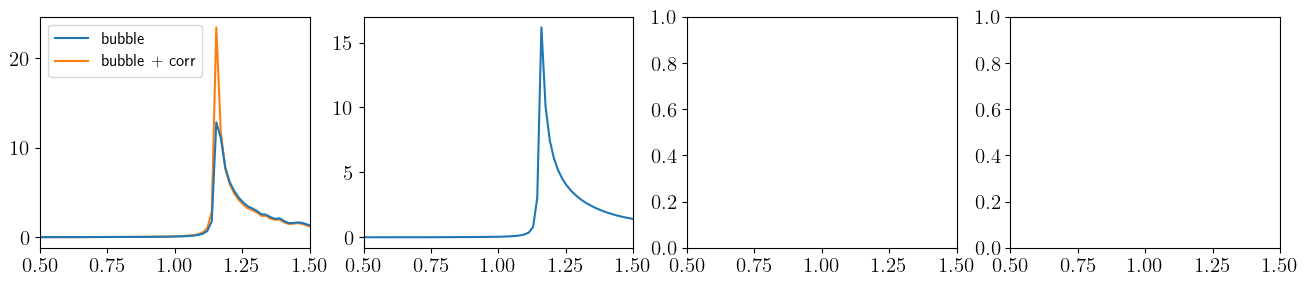

In [32]:
fig, ax = plt.subplots(ncols=4, figsize=(16,3))
ax[0].plot(omegas / m.gap, sigma_x, label='bubble')
ax[0].plot(omegas / m.gap, sigma_x + dsigma_x, zorder=-1, label='bubble + corr')
ax[0].legend()
for j in range(4):
    ax[j].set_xlim(0.5,1.5)
ax[1].plot(Omegas / m.gap, Sigma)
ax[1].plot(Omegas / m.gap, Sigma_full, zorder=-1)

ax[2].plot(omegas / m.gap, sigma_x)
ax[2].plot(Omegas / m.gap, Sigma)

ax[3].plot(omegas / m.gap, sigma_x + dsigma_x)
ax[3].plot(Omegas / m.gap, Sigma_full)

In [43]:


''' numerical parameters for the self-consistent calculation '''
parameters1 = {'n_pass' : 1e-4,
'epsilon_threshold' : 1e-8,
'N_epsilon' : 5,
'maxiter' : 500,
'eps_last' : 1e-8,
'dmu' : 5.,
'mix2' : 0.001,
'mix3' : 1.5,
'faktor1' : 0.1,
'max_trials' : 15,
'eps0' : 0.03,
}

parameters2 = {'n_pass' : 1e-4,
'epsilon_threshold' : 1e-8,
'N_epsilon' : 5,
'maxiter' : 500,
'eps_last' : 1e-8,
'dmu' : 5.,
'mix2' : 0.001,
'mix3' : 1.5,
'faktor1' : 0.1,
'max_trials' : 15,
'eps0' : 0.03,
}



phys_parameters = [b, t, t_, t12, epsilon, epsilon_, Vb, Vc, delta]

print(f'started', flush=True)
m = mt.model(Nk, mu0, phys_parameters, parameters1, parameters2, include_hartree)
m.GS()
print(f'found ground state', flush=True)

''' 2. run simulation at a few temperature stept '''
scale = 1.008

T_gap = m.gap
T_steps = T_gap * np.array([0.01 + 0.003 * i for i in range(10)])
betas_stops = 1/T_steps
beta0 = betas_stops[0] * scale
stops = [int(np.emath.logn(scale, beta0/beta)) for beta in betas_stops]
print(f'set temperature stops', flush=True)
print(stops)
# redundant !
Nomega, eps = 1501, 1e-6
maxbrentq = 50
factor = 15
oms = [1e-8]

# choose specifics of simulation: duration, etc.
t0 = 2.
sigma = 0.02
dt = 0.0025
Omega = 0.
A0 = 0.01
t_max = 300
omega_min = 2 * np.pi / t_max
Ncorr = 10
tol = 1e-8

Gammas =  [0.01]

omegas = np.logspace(-4,1,150)

for i in range(len(T_steps) - 1):
    print(f'temp stop {i}', flush=True)
    N = int(np.emath.logn(scale, betas_stops[i] / betas_stops[i+1]))
    betas = betas_stops[i]/scale**np.arange(1,N)
    stops = np.arange(1,N-1)
    Nomega, eps = 1001, 1e-6
    m.run_Tdependence(betas, stops, Gammas, Nomega, eps, maxbrentq, N, factor, oms, evaluate_transport=False)
    m.next_T(m.Ts[-1], 1)
    rho_init = m.rho.copy()

    for g, Gamma in enumerate(Gammas):
        print(f'Gamma={Gamma}', flush=True)
        Gamma_ = Gamma / 2
        #results = m.chijrho(m.Ts[-1], omegas, Gamma, N, factor, m.mu)

        T = m.Ts[-1]
        epsilon_max = np.sqrt(np.abs(np.arccosh(1/(eps*4*T))) * 2 * T)
        epsilons = np.linspace(-epsilon_max, epsilon_max, Nomega)
        mfd1 = -ht.fd_1(epsilons, T)
        spektralka = ht.Spektralka(epsilons, m.mu, m.energije, Gamma)
        phi = ht.phi_Kubo(m.K, m.tok_tilde, m.tok_tilde, spektralka, epsilons)
        L11 = np.pi * ht.integral_omega(phi * mfd1, epsilons)

        # [ case 1: Hartree-Fock frozen ]
        do_freeze = True
        time_f, measurements_f = ht.simulate_pulz(m.K, m.hk0, rho_init.copy(), phys_parameters, include_hartree, m.tok, [m.tok, m.hop],
                                            A0, t0, sigma, Omega, dt, t_max, Gamma_, do_freeze, Ncorr, tol,
                                            m.geom, m.phases, m.g_ffts, show_print=True)

        # [ case 2: Hartree-Fock dynamic
        # in case of Vc=0, no need to waste time with this because I know it equals zero]
        do_freeze = False
        time, measurements = ht.simulate_pulz(m.K, m.hk0, rho_init.copy(), phys_parameters, include_hartree, m.tok, [m.tok, m.tok_jE_hop],
                                            A0, t0, sigma, Omega, dt, t_max, Gamma_, do_freeze, Ncorr, tol,
                                            m.geom, m.phases, m.g_ffts, show_print=True)
        
        data = {'results' : results,
            'measurements_f' : measurements_f,
            'time' : time_f,
            'measurements' : measurements,
            'T' : m.Ts[-1],
            'L11' : L11,
            'Gamma' : Gamma,
            'Gamma_' : Gamma_}
    


started
found ground state
set temperature stops
[1, 33, 59, 81, 99, 115, 130, 142, 154, 165]
temp stop 0
started
0.0
59.626690692031616 9.662103450658321e-09 0.9999999999999991 -0.6842111457095696 -0.1846061717709339
0.03225806451612903
59.153462988126606 9.663118583080887e-09 1.0 -0.6842111457127807 -0.18460617177072844
0.06451612903225806
58.68399105964941 9.662103450658321e-09 0.9999999999999991 -0.6842111457095696 -0.1846061717709339
0.0967741935483871
58.21824509885854 9.662103450658321e-09 0.9999999999999991 -0.6842111457095696 -0.1846061717709339
0.12903225806451613
57.756195534581884 9.662103450658321e-09 0.9999999999999991 -0.6842111457095696 -0.1846061717709339
0.16129032258064516
57.29781303033917 9.662103450658321e-09 0.9999999999999991 -0.6842111457095696 -0.1846061717709339
0.1935483870967742
56.84306848247932 9.662103450658321e-09 0.9999999999999991 -0.6842111457095696 -0.1846061717709339
0.22580645161290322
56.391933018332665 9.662103450658321e-09 0.9999999999999991 -0

KeyboardInterrupt: 

In [3]:

''' 2. go to small but finite temperature '''
beta0 = 20
scale = 1.005
betas = beta0/scale**np.arange(1,3)
stops = [int(np.emath.logn(scale, beta0/beta)) for beta in betas]
Ts = 1/betas
Gammas = [0.01]
maxbrentq = 50
N = 15
factor = 5
nfit = 5
# Nomega, eps put to random small values because I am not interested in transport coefficients now
Nomega, eps = 1001, 1e-6
oms = [1e-3]
m.run_Tdependence(betas, stops, Gammas, Nomega, eps, maxbrentq, N, factor, oms, evaluate_transport=False)

started
0.0
19.900497512437813 7.81708131558645e-09 0.9999999996470408 0.4667907213312721 0.09936857301647686
0.5
19.80149006212718 7.817093250483964e-09 0.9999999996676794 0.4667907169100993 0.09936857243967573


In [8]:
''' 5. compute optical conductivity the other way, calculating susceptibilities
compare two types of bubbles  '''
    
omega = np.logspace(-6,0.1,101) * m.gap
T = m.Ts[-1]
N = 15
factor = 5
Gamma = 0.01
width = N * max(Gamma, T)
deps = min(Gamma, T) / factor

rhos, thetas = rho_operators(m.K, phys_parameters, include_hartree)
tok_tilde = operator_tilde(m.tok, m.vecs)
rhos_tilde = operator_tilde(rhos, m.vecs)
hop_tilde = operator_tilde(m.hop, m.vecs)
Gamma = 0.05

m1,m2,m3,m4 = compute_all_mf_matrices(m.K, m.rho, m.geom, m.phases, m.g_ffts)
mat_tilde = operator_tilde(m1+m2+m3+m4, m.vecs)

omegas = np.linspace(0.01, m.gap * 3, 50)
results = chi_jrho2(m.Nk, tok_tilde, hop_tilde, rhos_tilde, mat_tilde, -thetas, m.energije, m.mu, T, omegas, Gamma, include_hartree, N, factor)
results2 = chi_jrho2(m.Nk, tok_tilde, hop_tilde, rhos_tilde, mat_tilde, thetas, m.energije, m.mu, T, omegas, Gamma, include_hartree, N, factor)


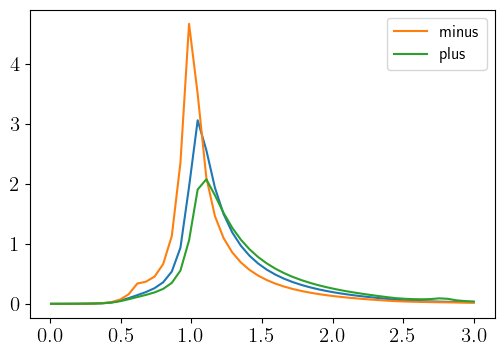

In [15]:
plt.plot(omegas / m.gap, results['j_j'].imag / omegas)
plt.plot(omegas / m.gap, results['j_j'].imag / omegas + results['d_j_j'].imag / omegas, label='minus')
plt.plot(omegas / m.gap, results2['j_j'].imag / omegas + results2['d_j_j'].imag / omegas, label='plus')
plt.legend()

np.float64(-0.16884390217561498)

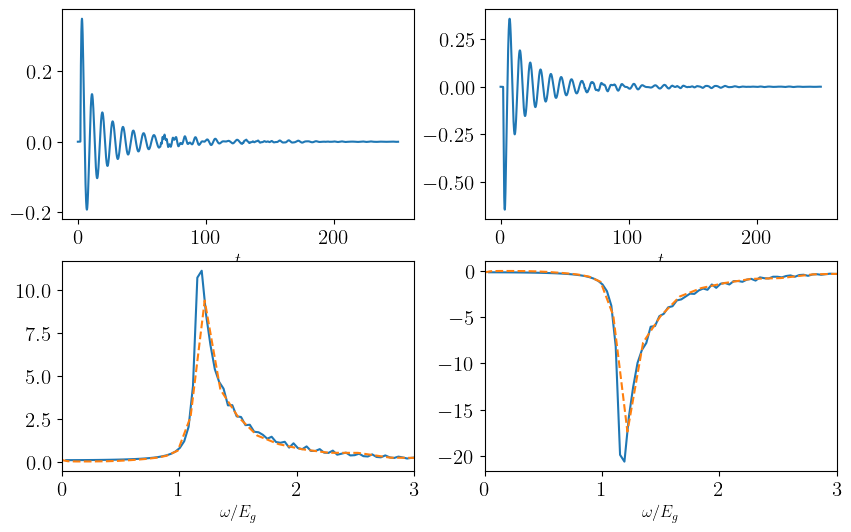

In [180]:
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(10,6))
eta = 1/t_max * 3
pulz = A_pulz(time_f, A0, t0, sigma, Omega)

for j in range(2):
    ax[0,j].plot(time_f, measurements_f[:,j].real * np.exp(-eta * time_f))
    omegas, resp = optical_conductivity(time_f, measurements_f[:,j].real, pulz, eta, 100, m.Nk)
    ax[1,j].plot(omegas / m.gap, resp, )
    ax[1,j].set_xlim(0,3)
    ax[0,j].set_xlabel(r'$t$')
    ax[1,j].set_xlabel(r"$\omega/E_g$")

ax[1,0].plot(oms / m.gap, results['j_j'].imag / oms, '--')
ax[1,1].plot(oms / m.gap, results['hop_j'].imag / oms, '--')
#ax[1,0].set_ylim(l11-0.1, l11+0.1)
(results['hop_j'].imag / oms)[0]

In [113]:
np.allclose(results['d_jE2_j'], 0.)

True

In [42]:
T = m.Ts[-1]
epsilon_max = np.sqrt(np.abs(np.arccosh(1/(eps*4*T))) * 2 * T)
epsilons = np.linspace(-epsilon_max, epsilon_max, Nomega)

spektralka = ht.Spektralka(epsilons, m.mu, m.energije, Gamma)
phi = ht.phi_Kubo(m.K, m.tok_tilde, m.tok_tilde, spektralka, epsilons)
phiQ = ht.phi_Kubo(m.K, m.mat_tilde, m.tok_tilde, spektralka, epsilons)
mfd1 = -ht.fd_1(epsilons, T)
l11 = np.pi * ht.integral_omega(phi * mfd1, epsilons)
l12 = np.pi * ht.integral_omega(epsilons * phi * mfd1, epsilons)
l12q = np.pi * ht.integral_omega(phiQ * mfd1, epsilons)

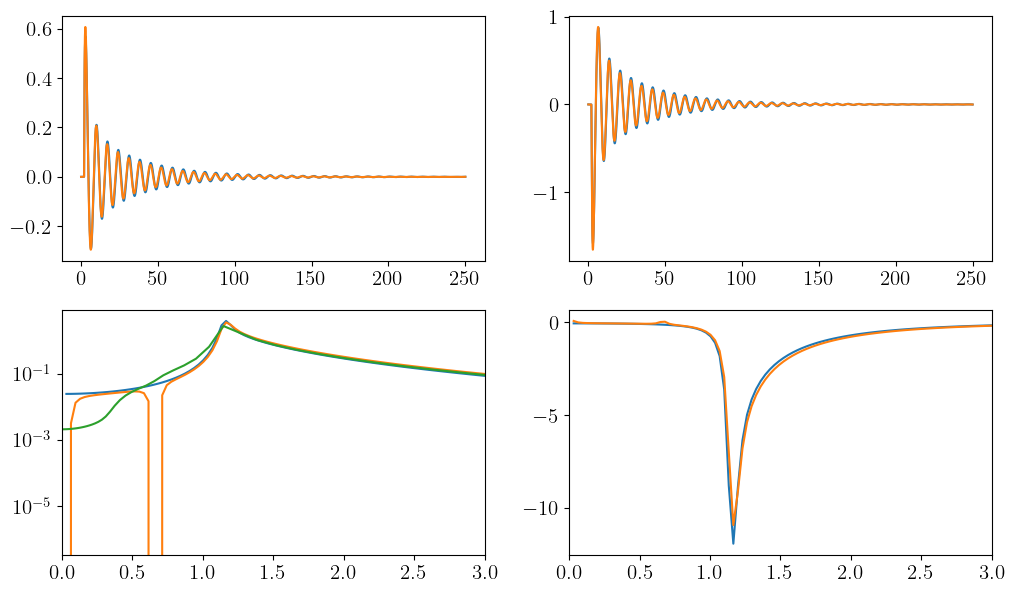

In [44]:
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(12,7))
pulz = A_pulz(time, A0, t0, sigma, Omega)
eta = 1/t_max

for j in range(2):
    ax[0,j].plot(time_f, measurements_f[:,j].real)
    ax[0,j].plot(time_f, measurements[:,j].real)
    omegas_f, signal_f = optical_conductivity(time_f, measurements_f[:,j].real, pulz, eta, 100 * m.gap, m.Nk)
    ax[1,j].plot(omegas_f / m.gap, signal_f)
    omegas, signal = optical_conductivity(time, measurements[:,j].real, pulz, eta, 100 * m.gap, m.Nk)
    ax[1,j].plot(omegas / m.gap, signal)
    ax[1,j].set_xlim(0,3)

ax[1,0].plot(oms / m.gap, results['j_j'].imag / oms)
#ax[1,1].plot(oms / m.gap, results['jE_j'].imag / oms * m.Nk)
ax[1,0].set_yscale('log')

0
1
2


SystemError: CPUDispatcher(<function Pi_bubble_w at 0x12fcb3c40>) returned a result with an exception set

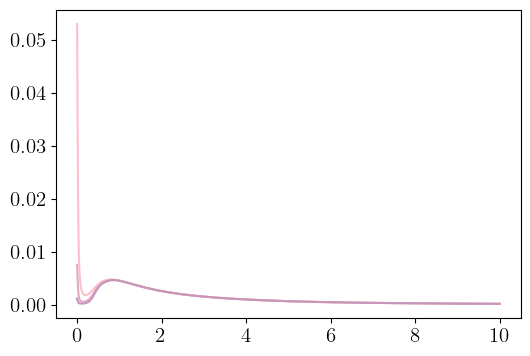

In [27]:
N = 15
factor = 5
oms = np.logspace(-5,1,100)
Gamma = 1e-2
T = 1/100
pulz = A_pulz(time, A0, t0, sigma, Omega)
betas = np.arange(3,22) * 5
Ts = 1/betas
for i, T in enumerate(Ts):
    results = m.chijrho(T, oms, Gamma, N, factor)
    plt.plot(oms, results['j_j'].imag / oms, color=colorFader('pink', 'navy', i / 9), label=T)
    print(i)

plt.xscale('log')
plt.legend()
plt.yscale('log')


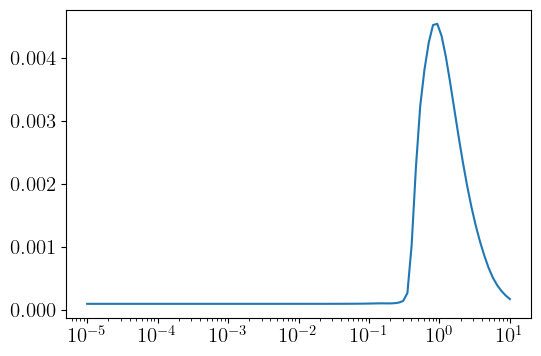

In [24]:
plt.plot(oms, results['j_j'].imag / oms)
plt.xscale('log')

False

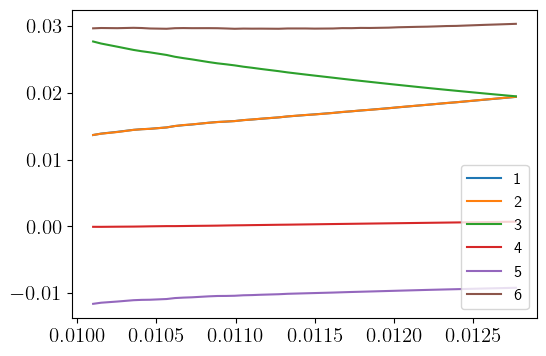

In [4]:
plt.plot(data['Ts'], - data['L12'] /  data['L11'] / data['Ts'], label='1')
plt.plot(data['Ts'], - data['L12_0'] /  data['L11_0'] / data['Ts'], label='2')
plt.plot(data['Ts'], - data['L12_corr'] /  data['L11_0'] / data['Ts'], label='3')
plt.plot(data['Ts'], - data['L12q_0'] /  data['L11_0'] / data['Ts'], label='4')
plt.plot(data['Ts'], - data['L12q_corr'] /  (data['L11_0'] + data['L11_corr'])/ data['Ts'], label='5')
plt.plot(data['Ts'], - (data['L12_0'] + data['L12_corr'] + data['L12q_0'] + data['L12q_corr']) /  (data['L11_0'] + data['L11_corr'])/ data['Ts'], label='6')
plt.legend()

np.allclose(data['L12q_0'], 0)

In [25]:
Gamma = 0.01
T = m.Ts[-1]
epsilon_max = np.sqrt(np.abs(np.arccosh(1/(eps*4*T))) * 2 * T)
epsilons = np.linspace(-epsilon_max, epsilon_max, Nomega)
spektralka = ht.Spektralka(epsilons, m.mu, m.energije, Gamma)
tok_tilde = ht.operator_tilde(m.tok, m.vecs)
phi = ht.phi_Kubo(m.K, tok_tilde, tok_tilde, spektralka, epsilons)
mfd1 = -ht.fd_1(epsilons, T)
L11 = np.pi * ht.integral_omega(phi * mfd1, epsilons)
L12 = np.pi * ht.integral_omega(phi * epsilons * mfd1, epsilons)

rhos_tilde = ht.operator_tilde(m.rhos, m.vecs)
m1, m2, m3, m4 = ht.compute_all_mf_matrices(m.K, m.rho, m.geom, m.phases, m.g_ffts)
mat = m1 + m2 + m3 + m4
mat_tilde = ht.operator_tilde(mat, m.vecs)
oms2 = np.logspace(-7,0.1,31)
results = ht.chi_jrho2(m.Nk, tok_tilde, rhos_tilde, mat_tilde, m.thetas, m.energije, m.mu, T, oms2, Gamma, N, factor)

In [34]:
results['jE_j'], np.max(np.abs(m.L12q_0))

(array([ 0.0815401 -6.41375156e-14j,  0.08153712-1.04240422e-13j,
         0.08153197-1.89054658e-13j,  0.08152308-3.29687862e-13j,
         0.08150776-5.84666921e-13j,  0.08148134-1.01016929e-12j,
         0.08143578-1.73541122e-12j,  0.08135722-3.00794189e-12j,
         0.08122175-5.18262141e-12j,  0.08098815-8.94296676e-12j,
         0.08058541-1.54312125e-11j,  0.07989115-2.66110052e-11j,
         0.07869472-4.58748228e-11j,  0.07663391-7.90677471e-11j,
         0.07308727-1.36364849e-10j,  0.06699256-2.34670079e-10j,
         0.05654567-4.03700465e-10j,  0.0387165 -6.92431749e-10j,
         0.00851331-1.18521482e-09j, -0.04201318-2.01655189e-09j,
        -0.12478205-3.40499955e-09j, -0.25578313-5.67376673e-09j,
        -0.45207253-9.26440184e-09j, -0.7222082 -1.42489666e-08j,
        -1.04099682-1.33996909e-08j, -1.2250631 +5.85724697e-08j,
        -1.54841476-1.04230010e-07j, -1.83604298-3.00444772e-05j,
        -2.04485782-8.93340568e-05j, -2.17533622+2.97018947e-02j,
        -2

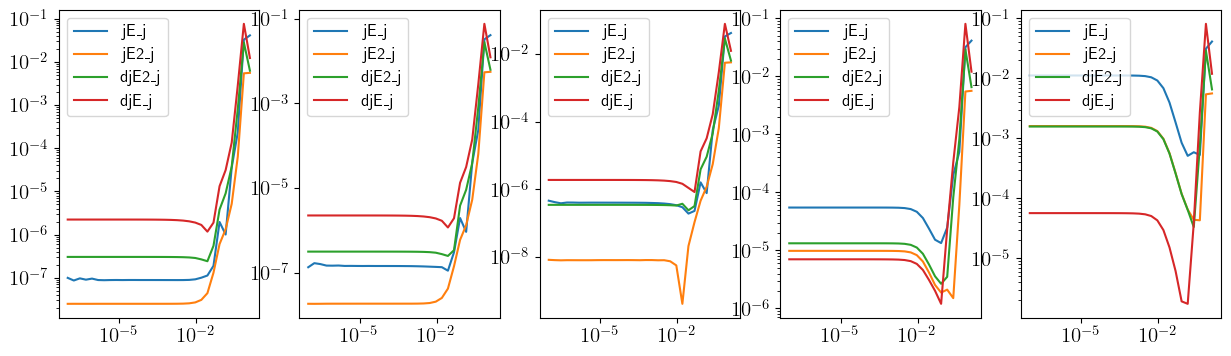

In [3]:
Ts = [m.gap / 100, m.gap / 80, m.gap / 50, m.gap / 20, m.gap / 10]
fig, ax = plt.subplots(ncols=len(Ts), figsize=(3*len(Ts), 4))
for i, T in enumerate(Ts):
    Gamma = 0.01
    epsilon_max = np.sqrt(np.abs(np.arccosh(1/(eps*4*T))) * 2 * T)
    epsilons = np.linspace(-epsilon_max, epsilon_max, Nomega)
    spektralka = ht.Spektralka(epsilons, m.mu, m.energije, Gamma)
    tok_tilde = ht.operator_tilde(m.tok, m.vecs)
    phi = ht.phi_Kubo(m.K, tok_tilde, tok_tilde, spektralka, epsilons)
    mfd1 = -ht.fd_1(epsilons, T)
    L11 = np.pi * ht.integral_omega(phi * mfd1, epsilons)
    L12 = np.pi * ht.integral_omega(phi * epsilons * mfd1, epsilons)

    rhos_tilde = ht.operator_tilde(m.rhos, m.vecs)
    m1, m2, m3, m4 = ht.compute_all_mf_matrices(m.K, m.rho, m.geom, m.phases, m.g_ffts)
    mat = m1 + m2 + m3 + m4
    mat_tilde = ht.operator_tilde(mat, m.vecs)
    oms2 = np.logspace(-7,0.1,31)
    results = ht.chi_jrho2(m.Nk, tok_tilde, rhos_tilde, mat_tilde, m.thetas, m.energije, m.mu, T, oms2, Gamma, N, factor)
    ax[i].plot(oms2, np.abs(results['jE_j'].imag / oms2), label='jE_j')
    ax[i].plot(oms2, np.abs(results['jE2_j'].imag / oms2), label='jE2_j')
    ax[i].plot(oms2, np.abs(results['d_jE2_j'].imag / oms2), label='djE2_j')
    ax[i].plot(oms2, np.abs(results['d_jE_j'].imag / oms2), label='djE_j')
    ax[i].legend()
    ax[i].set_xscale('log')
    ax[i].axhline(L12)
    ax[i].set_yscale('log')


In [4]:
Gamma = 0.01
T = m.gap / 50
epsilon_max = np.sqrt(np.abs(np.arccosh(1/(eps*4*T))) * 2 * T)
epsilons = np.linspace(-epsilon_max, epsilon_max, Nomega)
spektralka = ht.Spektralka(epsilons, m.mu, m.energije, Gamma)
tok_tilde = ht.operator_tilde(m.tok, m.vecs)
phi = ht.phi_Kubo(m.K, tok_tilde, tok_tilde, spektralka, epsilons)
mfd1 = -ht.fd_1(epsilons, T)
L11 = np.pi * ht.integral_omega(phi * mfd1, epsilons)
L12 = np.pi * ht.integral_omega(phi * epsilons * mfd1, epsilons)

rhos_tilde = ht.operator_tilde(m.rhos, m.vecs)
m1, m2, m3, m4 = ht.compute_all_mf_matrices(m.K, m.rho, m.geom, m.phases, m.g_ffts)
mat = m1 + m2 + m3 + m4
mat_tilde = ht.operator_tilde(mat, m.vecs)
oms2 = np.logspace(-7,0.1,31)
results = ht.chi_jrho2(m.Nk, tok_tilde, rhos_tilde, mat_tilde, m.thetas, m.energije, m.mu, T, oms2, Gamma, N, factor)

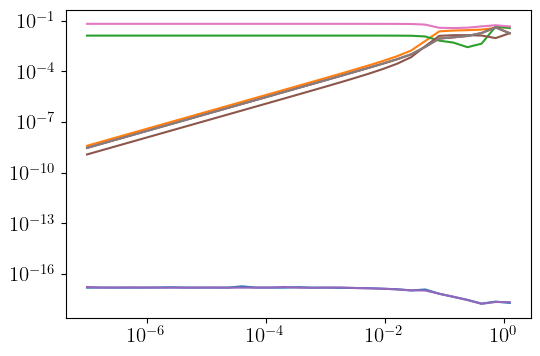

In [7]:
results['jE2_rho'].shape
for i in range(results['jE2_rho'].shape[0]):
    plt.plot(oms2, np.abs(results['jE2_rho'][i]))
plt.yscale('log')
plt.xscale('log')

(-2.0, 5.0)

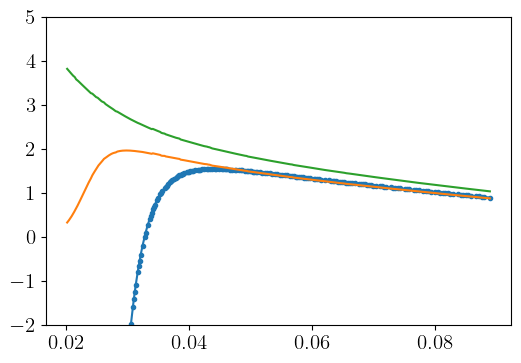

In [59]:
plt.plot(data['Ts'], -(data['L12_0'] + data['L12_corr'] + data['L12q_0'] + data['L12q_corr'])/(data['L11_0'] + data['L11_corr']) / data['Ts'], '.-')
plt.plot(data['Ts'], -data['L12_0']/(data['L11_0']) / data['Ts'])
plt.plot(data['Ts'], -data['L12_boltz'] / data['L11_boltz'] / data['Ts'])
plt.ylim(-2,5)

In [54]:
''' 2. go to small but finite temperature '''
beta0 = 80
scale = 1.005
betas = beta0/scale**np.arange(1,31)
stops = [int(np.emath.logn(scale, beta0/beta)) for beta in betas]
Ts = 1/betas
Gammas = [0.005]
maxbrentq = 15
N = 15
factor = 5
oms = [1e-6, 1e-5]
nfit = 5
# Nomega, eps put to random small values because I am not interested in transport coefficients now
Nomega, eps = 1001, 1e-4
m.run_Tdependence(betas, stops, Gammas, Nomega, eps, maxbrentq, N, factor, oms, nfit)

started
79.60199004975125 9.500761732894603e-09 0.9999999999780029 -0.08807334995293842 -0.014318547534147102
started evaluating at beta=79.20596024850872
79.20596024850872 9.497957226267673e-09 0.9999999959469713 -0.08807101701747662 -0.014318167653884434
calc chi
calc chi done
started evaluating at beta=78.81190074478481
78.81190074478481 9.551481744418666e-09 0.9999999999756836 -0.0880686035846621 -0.014317774640534575
calc chi
calc chi done
78.41980173610429 9.578056792136636e-09 0.9999999999744472 -0.088066107686239 -0.014317368211298712
started evaluating at beta=78.0296534687605
78.0296534687605 9.574086301533669e-09 0.999999995441686 -0.08806352694626224 -0.014316947980858124
calc chi
calc chi done
77.64144623757264 9.633747605208853e-09 0.9999999999718016 -0.08806085850256475 -0.0143165134407654
started evaluating at beta=77.25517038564442
77.25517038564442 9.628879721335082e-09 0.9999999950748893 -0.08805810041801032 -0.014316064333248583
calc chi
calc chi done
started evalua

In [36]:
data = m.collect_data()

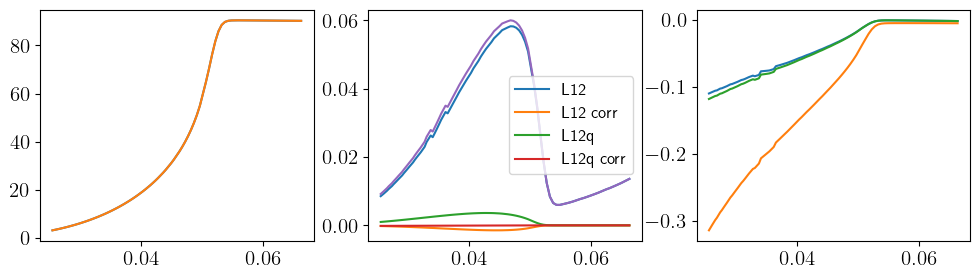

In [50]:
fig, ax = plt.subplots(ncols=3, figsize=(12,3)) 
ax[0].plot(data["Ts"], data["L11_0"])
ax[0].plot(data["Ts"], data["L11_0"])

ax[1].plot(data["Ts"], data["L12_0"], label='L12')
ax[1].plot(data["Ts"], data["L12_corr"], label='L12 corr')
ax[1].plot(data["Ts"], data["L12q_0"], label='L12q')
ax[1].plot(data["Ts"], data["L12q_corr"], label='L12q corr')
ax[1].legend()
ax[1].plot(data["Ts"], data["L12_0"] + data["L12_corr"] + data["L12q_0"] + data["L12q_corr"], label='full')

ax[2].plot(data["Ts"], - data["L12_0"] / data["L11_0"] / data["Ts"])
ax[2].plot(data["Ts"], - data["L12_boltz"] / data["L11_boltz"] / data["Ts"])
ax[2].plot(data["Ts"], - (data["L12_0"] + data["L12_corr"] + data["L12q_0"] + data["L12q_corr"]) / data["L11_0"] / data["Ts"])


In [8]:
Gamma = 0.01
Nomega = 1001
eps = 1e-6
tok_tilde = ht.operator_tilde(m.tok, m.vecs)
mat = ht.compute_all_mf_matrices(m.K, m.rho, m.geom, m.phases, m.g_ffts)
mat_tilde = ht.operator_tilde(mat, m.vecs)
rhos_tilde = ht.operator_tilde(m.rhos, m.vecs)
K0b, K1b = ht.Kn_boltz(m.K, m.energije, m.mu, m.Ts[-1])
T = m.Ts[-1]
epsilon_max = np.sqrt(np.abs(np.arccosh(1/(eps*4*T))) * 2 * T)
epsilons = np.linspace(-epsilon_max, epsilon_max, Nomega)
mfd1 = -ht.fd_1(epsilons, T)
spektralka = ht.Spektralka(epsilons, m.mu,m.energije, Gamma)
phi = ht.phi_Kubo(m.K, tok_tilde, tok_tilde, spektralka, epsilons)
l11 = np.pi * ht.integral_omega(phi * mfd1, epsilons)
l12 = np.pi * ht.integral_omega(epsilons * phi * mfd1, epsilons)
oms = [1e-6]
results = ht.chi_jrho2(m.Nk, tok_tilde, rhos_tilde, mat_tilde, m.thetas, m.energije, m.mu, T, oms, Gamma, m.include_hartree, N, factor)

In [13]:
results

{'j_j': array([0.76940735+1.54115096e-06j]),
 'rhorho': array([[[ 1.33984873e-01+4.79491304e-06j],
         [-1.56501825e-03-2.50679808e-09j],
         [-3.69496100e-19-1.15987927e-21j],
         [-5.94663487e-02-1.60485750e-06j],
         [ 1.33984873e-01+4.79491304e-06j],
         [ 2.04578330e-03+7.96417202e-08j],
         [ 2.22044605e-19+7.58223237e-19j],
         [-5.94663487e-02-1.60485750e-06j]],
 
        [[-1.56501825e-03-2.50679808e-09j],
         [ 1.46238260e+00+3.35196466e-06j],
         [ 4.41198446e-15-1.79794202e-07j],
         [ 4.24008582e-02-1.95166508e-08j],
         [-1.56501825e-03-2.50679808e-09j],
         [ 4.69889462e-01+2.05409605e-06j],
         [ 3.15892325e-14-5.62302630e-07j],
         [ 4.24008582e-02-1.95166508e-08j]],
 
        [[ 5.55111512e-20-1.26377316e-21j],
         [-4.37694325e-15+1.79794202e-07j],
         [ 1.80595879e+00+1.28246226e-07j],
         [-1.37690936e-12+2.57763838e-06j],
         [-7.45931095e-20-2.78656091e-18j],
         [-3.24

In [9]:
results["j_j"].imag / oms[0], l11, results["jE_j"].imag / oms[0], l12

(array([1.54115096]),
 np.float64(1.5411509638578018),
 array([0.00408345]),
 np.float64(0.004083447502877026))

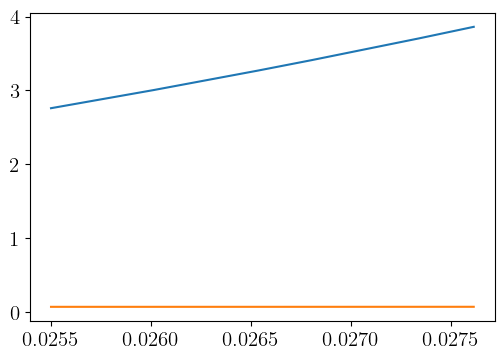

In [17]:
plt.plot(data["Ts"], data["L11_0"])
plt.plot(data["Ts"], data["L11"])

In [4]:
''' 3. calculate susceptibilities '''
omega = np.logspace(-6,1,31) * m.gap
T = m.Ts[-1]
N = 15
factor = 5
width = N * max(Gamma, T)
deps = min(Gamma, T) / factor

rhos, thetas = rho_operators(m.K, phys_parameters, include_hartree)
tok_tilde = operator_tilde(m.tok, m.vecs)
rhos_tilde = operator_tilde(rhos, m.vecs)

Gamma = 0.01

geom, phases = input_data(m.K, phys_parameters, m.mu)
g_ffts = G_ffts(phases, m.Nk)
Mat = compute_all_mf_matrices(m.K, m.rho, geom, phases, g_ffts)
Mat_tilde = operator_tilde(Mat, m.vecs)

results = chi_jrho2(m.K, tok_tilde, rhos_tilde, Mat_tilde, thetas, m.energije, m.mu, T, omega, Gamma, N=N, factor=factor)

sigma_2f = results["j_j"].imag / omega
dsigma_2 = results["d_j_j"].imag / omega

sigma_bare = sigma_2f[0]
deltasigma = dsigma_2[0]

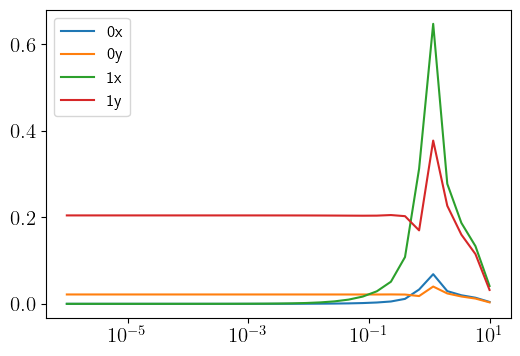

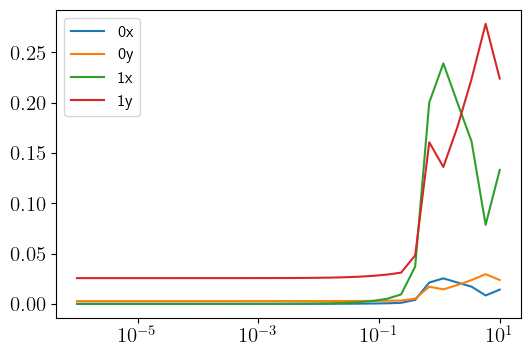

In [35]:
plt.plot(omega, np.abs(results["j_rho"][1]), label='0x')
plt.plot(omega, np.abs(results["j_rho"][2]), label='0y')
plt.plot(omega, np.abs(results["j_rho"][5]), label='1x')
plt.plot(omega, np.abs(results["j_rho"][6]), label='1y')
plt.legend()
plt.xscale('log')
plt.show()
plt.plot(omega, np.abs(results["jE_rho"][1]), label='0x')
plt.plot(omega, np.abs(results["jE_rho"][2]), label='0y')
plt.plot(omega, np.abs(results["jE_rho"][5]), label='1x')
plt.plot(omega, np.abs(results["jE_rho"][6]), label='1y')
plt.legend()
plt.xscale('log')

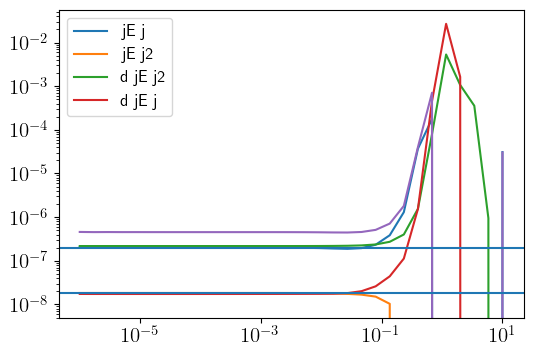

(np.float64(-0.052986168855650925), np.float64(-0.12109197988760406))

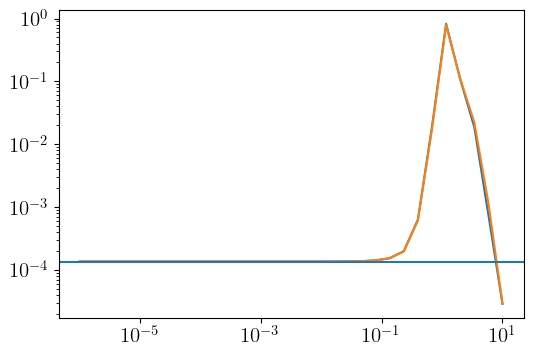

In [25]:
plt.plot(omega / m.gap, results["jE_j"].imag / omega, label='jE j')
plt.plot(omega / m.gap, results["jE_j2"].imag / omega, label='jE j2')
plt.plot(omega / m.gap, results["d_jE2_j"].imag / omega, label='d jE j2')
plt.plot(omega / m.gap, results["d_jE_j"].imag / omega, label='d jE j')

plt.plot(omega / m.gap, (results["jE_j"] + results["jE_j2"] + results["d_jE2_j"] + results["d_jE_j"]).imag / omega)

plt.legend()
plt.xscale('log')
plt.yscale('log')

epsilons = np.linspace(-2, 2, 5001)
A = Spektralka(epsilons, m.mu, m.energije, Gamma)
phiQ = phi_Kubo(m.K, Mat_tilde, tok_tilde, A, epsilons)
phi = phi_Kubo(m.K, tok_tilde, tok_tilde, A, epsilons)
chi_jE_j2 = chi_UV(m.K, Mat_tilde, tok_tilde, omega, m.energije, Gamma, m.mu, T, N, factor)
mfd1 = -fd_1(epsilons, T)
L12Q = np.pi * np.trapezoid(phiQ * mfd1, epsilons).real
L12 = np.pi * np.trapezoid(phi * epsilons * mfd1, epsilons).real
L11 = np.pi * np.trapezoid(phi * mfd1, epsilons).real
plt.axhline(L12)
plt.axhline(L12Q)
plt.show()
plt.plot(omega / m.gap, results["j_j"].imag / omega)
plt.plot(omega / m.gap, (results["j_j"] + results["d_j_j"]).imag / omega)
plt.axhline(L11)
plt.xscale('log')
plt.yscale('log')
L11_dressed = ((results["j_j"] + results["d_j_j"]).imag / omega)[0]
L12_dressed = ((results["jE_j"] + results["jE_j2"] + results["d_jE2_j"] + results["d_jE_j"]).imag / omega)[0]

Seebeck_bare = -L12 / L11 / T
Seebeck_dressed = -L12_dressed / L11_dressed / T
Seebeck_bare, Seebeck_dressed

In [ ]:
epsilons = np.linspace(-2, 2, 5001)
A = Spektralka(epsilons, m.mu, m.energije, Gamma)
phiQ = phi_Kubo(m.K, Mat_tilde, tok_tilde, A, epsilons)
chi_jE_j2 = chi_UV(m.K, Mat_tilde, tok_tilde, omega, m.energije, Gamma, m.mu, T, N, factor)
mfd1 = -fd_1(epsilons, T)
L12Q = np.pi * np.trapezoid(phiQ * mfd1, epsilons).real


(np.float64(1.83002684177355e-08),
 np.float64(1.829026500136381e-08),
 np.float64(4.578115818806372e-07))

In [34]:
epsilons = np.linspace(-2, 2, 5001)
A = Spektralka(epsilons, m.mu, m.energije, Gamma)
phi = phi_Kubo(m.K, tok_tilde, tok_tilde, A, epsilons)
phiQ = phi_Kubo(m.K, Mat_tilde, tok_tilde, A, epsilons)

mfd1 = -fd_1(epsilons, T)
L12 = np.pi * np.trapezoid(epsilons * phi * mfd1, epsilons).real
L12Q = np.pi * np.trapezoid(phiQ * mfd1, epsilons).real

sigma_DC = np.pi * np.trapezoid(phi * mfd1, epsilons).real

L12, L12Q


(np.float64(2.0011096395921689e-07), np.float64(1.83002684177355e-08))

(np.float64(2.001109721261338e-07), np.float64(2.044619748465283e-07))

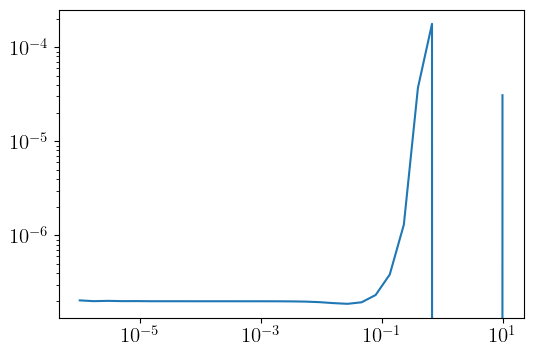

In [6]:
epsilons = np.linspace(-2, 2, 1001)
A = Spektralka(epsilons, m.mu, m.energije, Gamma)
phi = phi_Kubo(m.K, tok_tilde, tok_tilde, A, epsilons)
mfd1 = -fd_1(epsilons, T)
L12 = np.pi * np.trapezoid(epsilons * phi * mfd1, epsilons).real
sigma_DC = np.pi * np.trapezoid(phi * mfd1, epsilons).real

plt.plot(omega, chi_jE_j.imag / omega)
#plt.axhline(L12)
plt.yscale('log')
plt.xscale('log')

L12, chi_jE_j.imag[0] / omega[0]

In [5]:
''' 4. calculate DC bare conductivity as well as the first-order correction
calculate what you get if you use bare bubble with vertices to which dSigma/dk is added '''
epsilons = np.linspace(-2, 2, 1001)
A = Spektralka(epsilons, m.mu, m.energije, Gamma)
phi = phi_Kubo(m.K, tok_tilde, tok_tilde, A, epsilons)
mfd1 = -fd_1(epsilons, T)
sigma_DC = np.pi * np.trapezoid(phi * mfd1, epsilons).real

Bs, Cs = BandC(tok_tilde, rhos_tilde, thetas, m.energije, Gamma, m.mu, T, include_hartree, N, factor)
Dsigma = -Vb * Bs[0] * Cs[0] - Vc * Bs[1] * Cs[1]

''' now if I add dSigma/dk (k-derivative of self-energy) to current
and I compute DC conductivity from bubble but by changing current to current + dSigma/dk: on single vertex OR on both vertices of the bubble '''
dSigma_dk = np.zeros((2, 2, m.Nk), dtype=np.complex128)
dSigma_dk[0,1] = -1j * np.exp(-1j*m.K) * m.delta_c
dSigma_dk[1,0] = dSigma_dk[0,1].conjugate()
dSigma_dk_tilde = operator_tilde(dSigma_dk, m.vecs)

phi1 = phi_Kubo(m.K, tok_tilde + dSigma_dk_tilde, tok_tilde, A, epsilons)
sigma_DC1 = np.pi * np.trapezoid(phi1 * mfd1, epsilons).real
phi2 = phi_Kubo(m.K, tok_tilde + dSigma_dk_tilde, tok_tilde + dSigma_dk_tilde, A, epsilons)
sigma_DC2 = np.pi * np.trapezoid(phi2 * mfd1, epsilons).real

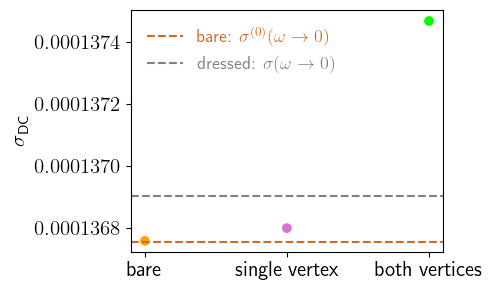

In [6]:


fig, ax = plt.subplots(figsize=(5,3))
c3, c4, c5 = 'orange', 'orchid', 'lime'
cols =[c3, c4, c5]
ax.scatter(range(3), [sigma_DC, sigma_DC1, sigma_DC2], color=cols)
ax.set_xticks(range(3))
ax.set_xticklabels(['bare', 'single vertex', 'both vertices'])
ax.set_ylabel(r'$\sigma_{\text{DC}}$', fontsize=15)

ax.axhline(sigma_bare, color='chocolate', ls='dashed', label=r'bare: $\sigma^{(0)}(\omega\to 0)$')
ax.axhline(sigma_bare + deltasigma, color='grey', ls='dashed', label=r'dressed: $\sigma(\omega\to 0)$')
leg = ax.legend(frameon=False, fontsize=13)
for text, line in zip(leg.get_texts(), leg.get_lines()):
    text.set_color(line.get_color())
plt.tight_layout()

spectral radius of chi_rhorho @ thetas is 0.9956150019846524


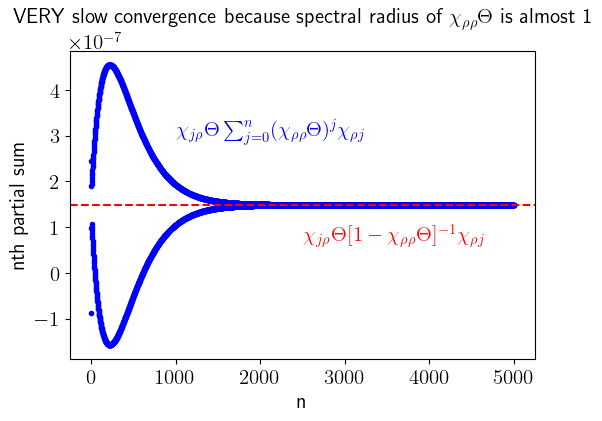

In [7]:
max_order = 5000
appr = ladder_terms(chi_j_rh2, chi_rh_rh2, chi_rh_j2, thetas, max_order)
plt.plot(range(len(appr)), np.cumsum(appr[:,0].imag / omega[0], axis=0), '.', color='blue')
plt.xlabel(r'n', fontsize=15)
plt.ylabel(r'nth partial sum', fontsize=15)
plt.text(1000, 3*1e-7, r'$\chi_{j \rho} \Theta \sum_{j=0}^n (\chi_{\rho\rho}\Theta)^j \chi_{\rho j}$', color='blue', fontsize=15)
plt.axhline(deltasigma, color='red', ls='dashed')
plt.text(2500, 0.7*1e-7, r'$\chi_{j \rho} \Theta [1 - \chi_{\rho\rho}\Theta]^{-1} \chi_{\rho j}$', color='red', fontsize=15)
plt.title(r'VERY slow convergence because spectral radius of $\chi_{\rho\rho}\Theta$ is almost 1')
ei = LA.eigvals(chi_rh_rh2[:,:,0] @ np.diag(thetas))
print(f'spectral radius of chi_rhorho @ thetas is {np.max(np.abs(ei))}')
if np.sign(ei[np.argmax(np.abs(ei))]) == -1:
    print(f'sign of max eig is negative')

np.float64(0.0010866729141108407)

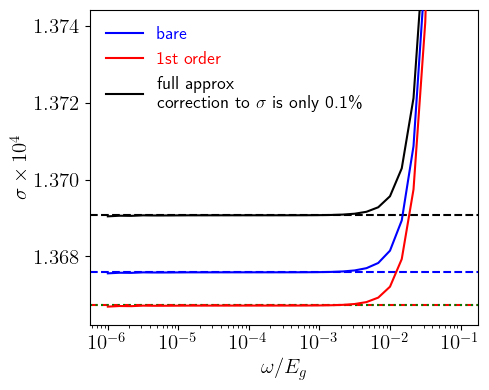

In [8]:
fig, ax = plt.subplots(figsize=(5,4))
ax.plot(omega / m.gap, 1e4 * chi_jj2.imag / omega, zorder=100, color='blue', label='bare')
ax.plot(omega / m.gap, 1e4 * chi_jj2.imag / omega + 1e4 * appr[0,:].imag / omega, zorder=100, color='red', label='1st order')
ax.plot(omega / m.gap, 1e4 * chi_jj2.imag / omega +  1e4 * dchi_jj2.imag/omega, color='black', label=r'full approx' + '\n' + rf'correction to $\sigma$ is only 0.1\%', )
ax.set_xscale('log')

ax.axhline(1e4 * sigma_DC, ls='dashed', color='blue')
ax.axhline(1e4 * sigma_DC + 1e4 * Dsigma, ls='dashed', color='red')
ax.axhline(1e4 * sigma_DC + 1e4 * deltasigma, color='black', ls='dashed')
ax.set_ylim(1e4 * sigma_DC * 0.999, 1e4 * sigma_DC * 1.005)

ax.axhline(1e4 * sigma_DC + 1e4 * Dsigma, color='green', ls='dotted', ms=20)

leg = ax.legend(frameon=False, fontsize=13)
for text, line in zip(leg.get_texts(), leg.get_lines()):
    text.set_color(line.get_color())
ax.set_xlabel(r'$\omega / E_g$', fontsize=15)
ax.set_ylabel(r'$\sigma \times 10^4$', fontsize=15)

plt.tight_layout()

deltasigma / sigma_DC
